# Figure 5-7 — Deformation-dependent permeability

This notebook evaluates the homogenized permeability under uniaxial stretch, simple shear, and pure shear loading while maintaining a prescribed macroscopic liquid-pressure gradient.

---

**Authors**

Haotian XIAO
Martin GENET

École Polytechnique, Palaiseau, France


## Imports

In [1]:
from pathlib import Path
import math
import sys

import dolfin
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pyvista as pv

import myPythonLibrary as mypy
import dolfin_mech as dmech

2026-06-25 22:00:50.612 (   0.020s) [          7E3240]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x1501475e0): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-25 22:00:50.612 (   0.020s) [          7E3240]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x1501475e0): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-25 22:00:50.612 (   0.020s) [          7E3240]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x1501475e0): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-25 22:00:50.612 (   0.020s) [          7E3240]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x1501475e0): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-25 22:00:50.612 (   0.020s) [          7E3240]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x1501475e0): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-25 22:00:50.612 (   0.020s) [          7E3240]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x1501475e0): Unsupported cell type: 56 Sett

## Project paths

In [2]:
def find_project_dir():
    current_dir = Path.cwd().resolve()

    for candidate in (current_dir, *current_dir.parents):
        if (
            (candidate / "demos").is_dir()
            and (candidate / "src").is_dir()
            and (candidate / "environment.yml").is_file()
        ):
            return candidate

    raise RuntimeError("Could not locate the project directory.")


PROJECT_DIR = find_project_dir()
SRC_DIR = PROJECT_DIR / "src"
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src
RESULTS_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/results


##Deformation-loading function

In [3]:
def run_deformation_mode(
    results_dir,
    mode,
    r0_list=(0.2,),
    probe_list=("gx", "gy"),
    perform_tests=0,
    beta=1.3,
):
    mode_to_folder = {
        "stretch-x": "Figure5_stretch_x",
        "stretch-y": "Figure6_stretch_y",
        "shear": "Figure7_shear",
        "pure-shear": "Pure_shear",
    }

    if mode not in mode_to_folder:
        raise ValueError(
            "mode must be 'stretch-x', 'stretch-y', "
            "'shear', or 'pure-shear'"
        )

    res_folder = Path(results_dir) / mode_to_folder[mode]
    res_folder.mkdir(parents=True, exist_ok=True)

    test = mypy.Test(
        res_folder=str(res_folder),
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    material_parameters = {
        "alpha": 0.16,
        "gamma": 0.5,
        "c1": 0.2,
        "c2": 0.4,
        "kappa": 1.0,
        "eta": 1e-5,
    }

    dim = 2
    n_steps = 2
    pf = 0.0

    def run_one_probe(r0, probe):
        if probe == "gx":
            gx_ini_lst = [0.0, 0.01]
            gx_fin_lst = [0.01, 0.01]
            gy_ini_lst = [0.0, 0.0]
            gy_fin_lst = [0.0, 0.0]

        elif probe == "gy":
            gx_ini_lst = [0.0, 0.0]
            gx_fin_lst = [0.0, 0.0]
            gy_ini_lst = [0.0, 0.01]
            gy_fin_lst = [0.01, 0.01]

        else:
            raise ValueError("probe must be 'gx' or 'gy'")

        res_basename = f"Fig4-{mode}-r0={r0}-pf={pf}-{probe}"
        result_basename = res_folder / res_basename
        mesh_filebasename = res_folder / f"mesh-r0={r0}"

        load_params = {
            "solid": {},
            "liquid": {},
            "air": {},
        }

        for i in range(dim):
            for j in range(dim):
                load_params["solid"][f"sigma_bar_{i}{j}"] = 0.0

        load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

        load_params["liquid"]["grad_p_bar_x_ini_lst"] = gx_ini_lst
        load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst
        load_params["liquid"]["grad_p_bar_y_ini_lst"] = gy_ini_lst
        load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

        load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

        if mode == "stretch-x":
            load_params["solid"]["U_bar_00_lst"] = [0.0, 0.3]

        elif mode == "stretch-y":
            load_params["solid"]["U_bar_11_lst"] = [0.0, 0.3]

        elif mode == "shear":
            load_params["solid"]["U_bar_00_lst"] = [0.0, 0.0]
            load_params["solid"]["U_bar_11_lst"] = [0.0, 0.0]
            load_params["solid"]["U_bar_01_lst"] = [0.0, 0.3]
            load_params["solid"]["U_bar_10_lst"] = [0.0, 0.0]

        elif mode == "pure-shear":
            load_params["solid"]["U_bar_00_lst"] = [
                0.0,
                beta - 1.0,
            ]
            load_params["solid"]["U_bar_11_lst"] = [
                0.0,
                1.0 / beta - 1.0,
            ]

        load_params["air"]["pf"] = pf
        load_params["air"]["pf_lst"] = [pf] * n_steps

        dmech.run_HollowBox_MicroPoroflow(
            dim=dim,
            mesh_params={
                "dim": dim,
                "xmin": 0.0,
                "ymin": -math.sqrt(3.0) / 2.0,
                "xmax": 1.0,
                "ymax": math.sqrt(3.0) / 2.0,
                "r0": r0,
                "l": 0.03,
                "hole_shape": "hex",
                "add_center_hole": True,
                "mesh_filebasename": str(mesh_filebasename),
            },
            mat_params={
                "skel": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "bulk": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "pore": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
            },
            flow_params={
                "k_l": dolfin.Constant(
                    (
                        (1e-6, 0.0),
                        (0.0, 1e-6),
                    )
                ),
                "use_kozeny_carman": False,
            },
            porosity_params={
                "type": "constant",
                "val": 0.3,
            },
            bcs="pbc",
            step_params={
                "n_steps": n_steps,
                "Deltat_lst": [1e-2, 1e-1],
                "dt_ini_lst": [1e-3, 1e-3],
                "dt_min_lst": [1e-4, 1e-4],
                "dt_max_lst": [5e-3, 5e-3],
            },
            load_params=load_params,
            res_basename=str(result_basename),
            verbose=0,
        )

        test.test(str(result_basename))

    for r0 in r0_list:
        for probe in probe_list:
            print(
                f"Running mode={mode}, "
                f"r0={r0}, "
                f"probe={probe}"
            )

            run_one_probe(
                r0=r0,
                probe=probe,
            )

    return res_folder

## Simulation parameters

In [4]:
r0_list = (0.072, 0.315, 0.41, 0.5)
mode_list = ("stretch-x", "stretch-y", "shear")
probe_list = ("gx", "gy")


## Numerical simulations

In [5]:
res_folders = {}

for mode in mode_list:
    res_folders[mode] = run_deformation_mode(
        results_dir=RESULTS_DIR,
        mode=mode,
        r0_list=r0_list,
        probe_list=probe_list,
    )

    print(f"Results for {mode} saved in: {res_folders[mode]}")

Running mode=stretch-x, r0=0.072, probe=gx
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Running mode=stretch-x, r0=0.072, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy

##Post-processing

In [6]:
from Plot_Microporoflow import plot_principal_K_vs_U

def build_deformation_figure(
    mode,
    res_folder,
    r0_list,
):
    mode_to_xcomponent = {
        "stretch-x": "xx",
        "stretch-y": "yy",
        "shear": "xy",
        "pure-shear": "xx",
    }

    mode_to_figure_name = {
        "stretch-x": "Figure5_stretch_x.pdf",
        "stretch-y": "Figure6_stretch_y.pdf",
        "shear": "Figure7_shear.pdf",
        "pure-shear": "Figure7_pure_shear.pdf",
    }

    if mode not in mode_to_xcomponent:
        raise ValueError(
            "mode must be 'stretch-x', 'stretch-y', "
            "'shear', or 'pure-shear'"
        )

    figures_folder = RESULTS_DIR / "figures"
    figures_folder.mkdir(parents=True, exist_ok=True)

    figure_path = figures_folder / mode_to_figure_name[mode]

    plot_principal_K_vs_U(
        res_folder=str(res_folder),
        res_basename_prefix=f"Fig4-{mode}",
        r0_list=r0_list,
        pf_list=(0.0,),
        x_component=mode_to_xcomponent[mode],
        stream_density=0.6,
        stream_grid_n=500,
        stream_scale=1.0,
        add_stream_colorbar=True,
        save_name=str(figure_path),
        show_plot=True,
    )

    return figure_path


## Figure5

[WARNING] Uyy differs between gx and gy probes for r0=0.072, pf=0.0
r0 = 0.072, pf = 0.0
K1_0 = 9.734762442214276e-07
K2_0 = 9.654762412521026e-07
max asymmetry = 5.656741288840471e-10


/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:540: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf0 = mesh0.extract_surface().triangulate()
/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:557: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf = warped.extract_surface().triangulate()


[WARNING] Uyy differs between gx and gy probes for r0=0.315, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.315, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.315, pf=0.0
r0 = 0.315, pf = 0.0
K1_0 = 5.35430502201224e-07
K2_0 = 5.333771416911918e-07
max asymmetry = 1.737356321115984e-08
[WARNING] Uyy differs between gx and gy probes for r0=0.41, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.41, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.41, pf=0.0
r0 = 0.41, pf = 0.0
K1_0 = 3.240750861201487e-07
K2_0 = 3.234028540336227e-07
max asymmetry = 5.162157950299376e-09
[WARNING] Uyy differs between gx and gy probes for r0=0.5, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.5, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.5, pf=0.0
r0 = 0.5, pf = 0.0
K1_0 = 1.413648453774125e-07
K2_0 = 1.4127279523913283e-07
max asymmetry = 3.239868540979667e-08


/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:1244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


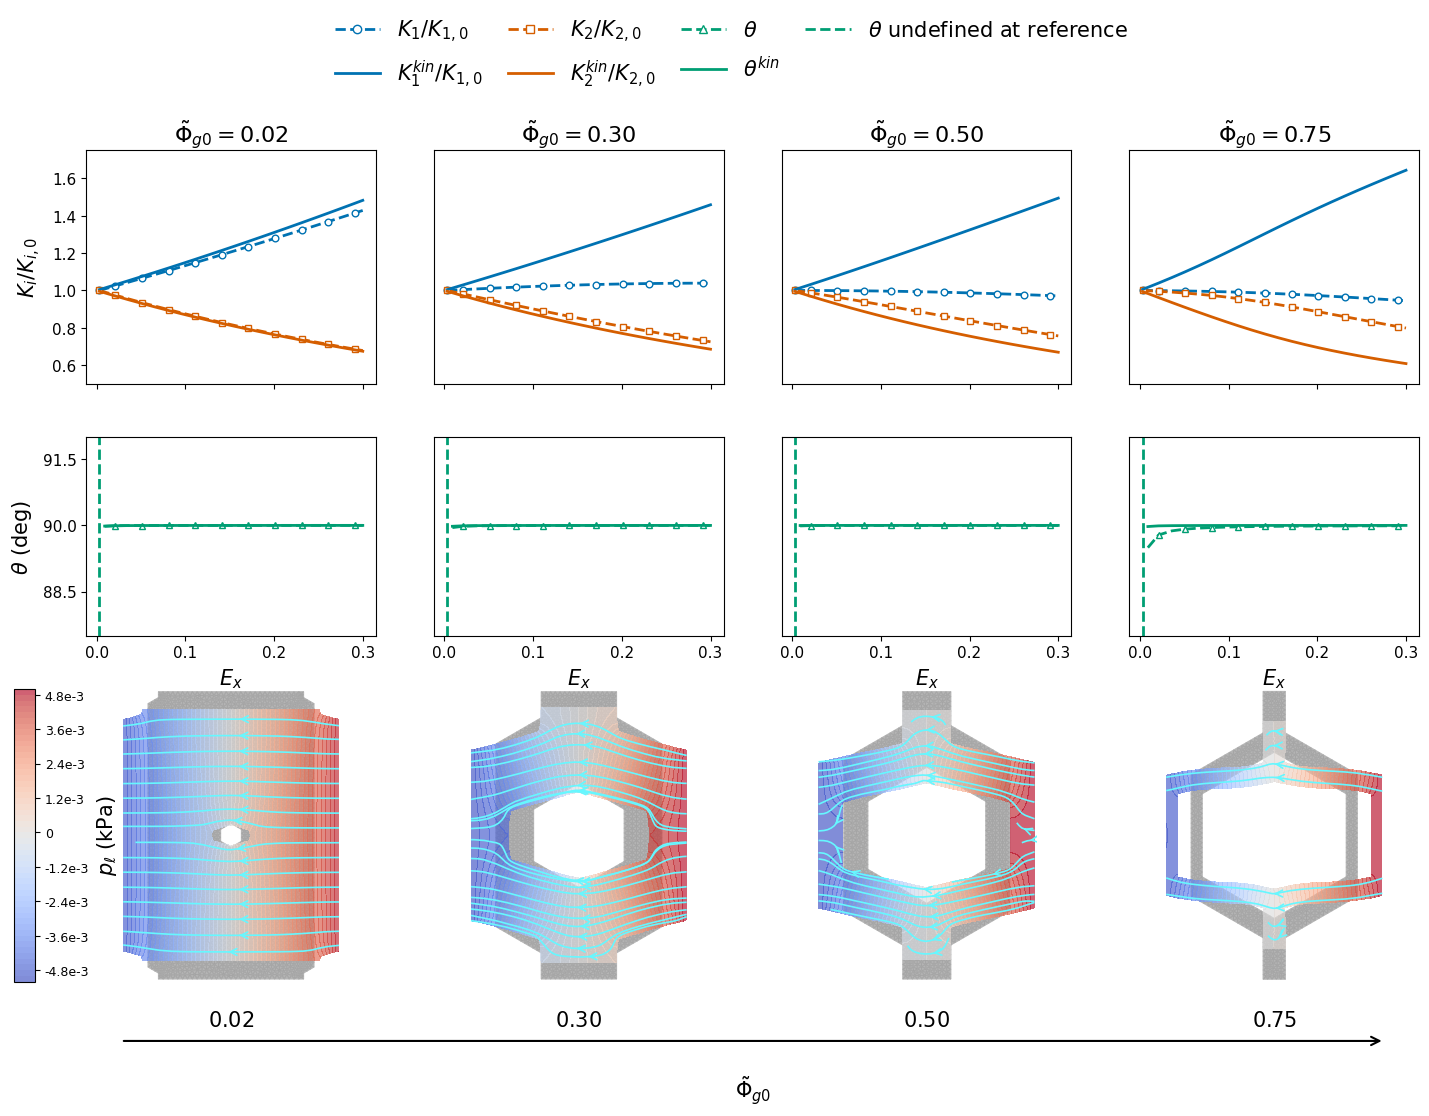

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure5_stretch_x.pdf
Figure saved in: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure5_stretch_x.pdf


In [7]:
figure_path = build_deformation_figure(
    mode="stretch-x",
    res_folder=res_folders["stretch-x"],
    r0_list=r0_list,
)

print("Figure saved in:", figure_path)

## Figure 6

[WARNING] Uxx differs between gx and gy probes for r0=0.072, pf=0.0
r0 = 0.072, pf = 0.0
K1_0 = 9.734833058323566e-07
K2_0 = 9.654686466225244e-07
max asymmetry = 4.967479841071805e-10


/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:540: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf0 = mesh0.extract_surface().triangulate()
/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:557: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf = warped.extract_surface().triangulate()


[WARNING] Uxx differs between gx and gy probes for r0=0.315, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.315, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.315, pf=0.0
r0 = 0.315, pf = 0.0
K1_0 = 5.354547682109034e-07
K2_0 = 5.333532979957465e-07
max asymmetry = 1.9440776408361853e-08
[WARNING] Uxx differs between gx and gy probes for r0=0.41, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.41, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.41, pf=0.0
r0 = 0.41, pf = 0.0
K1_0 = 3.240772361222316e-07
K2_0 = 3.234027357320239e-07
max asymmetry = 1.1123719371415744e-08
[WARNING] Uxx differs between gx and gy probes for r0=0.5, pf=0.0
[WARNING] Uxy differs between gx and gy probes for r0=0.5, pf=0.0
[WARNING] Uyx differs between gx and gy probes for r0=0.5, pf=0.0
r0 = 0.5, pf = 0.0
K1_0 = 1.4134989493568007e-07
K2_0 = 1.412884582374189e-07
max asymmetry = 3.257814023386929e-08


/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:1244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


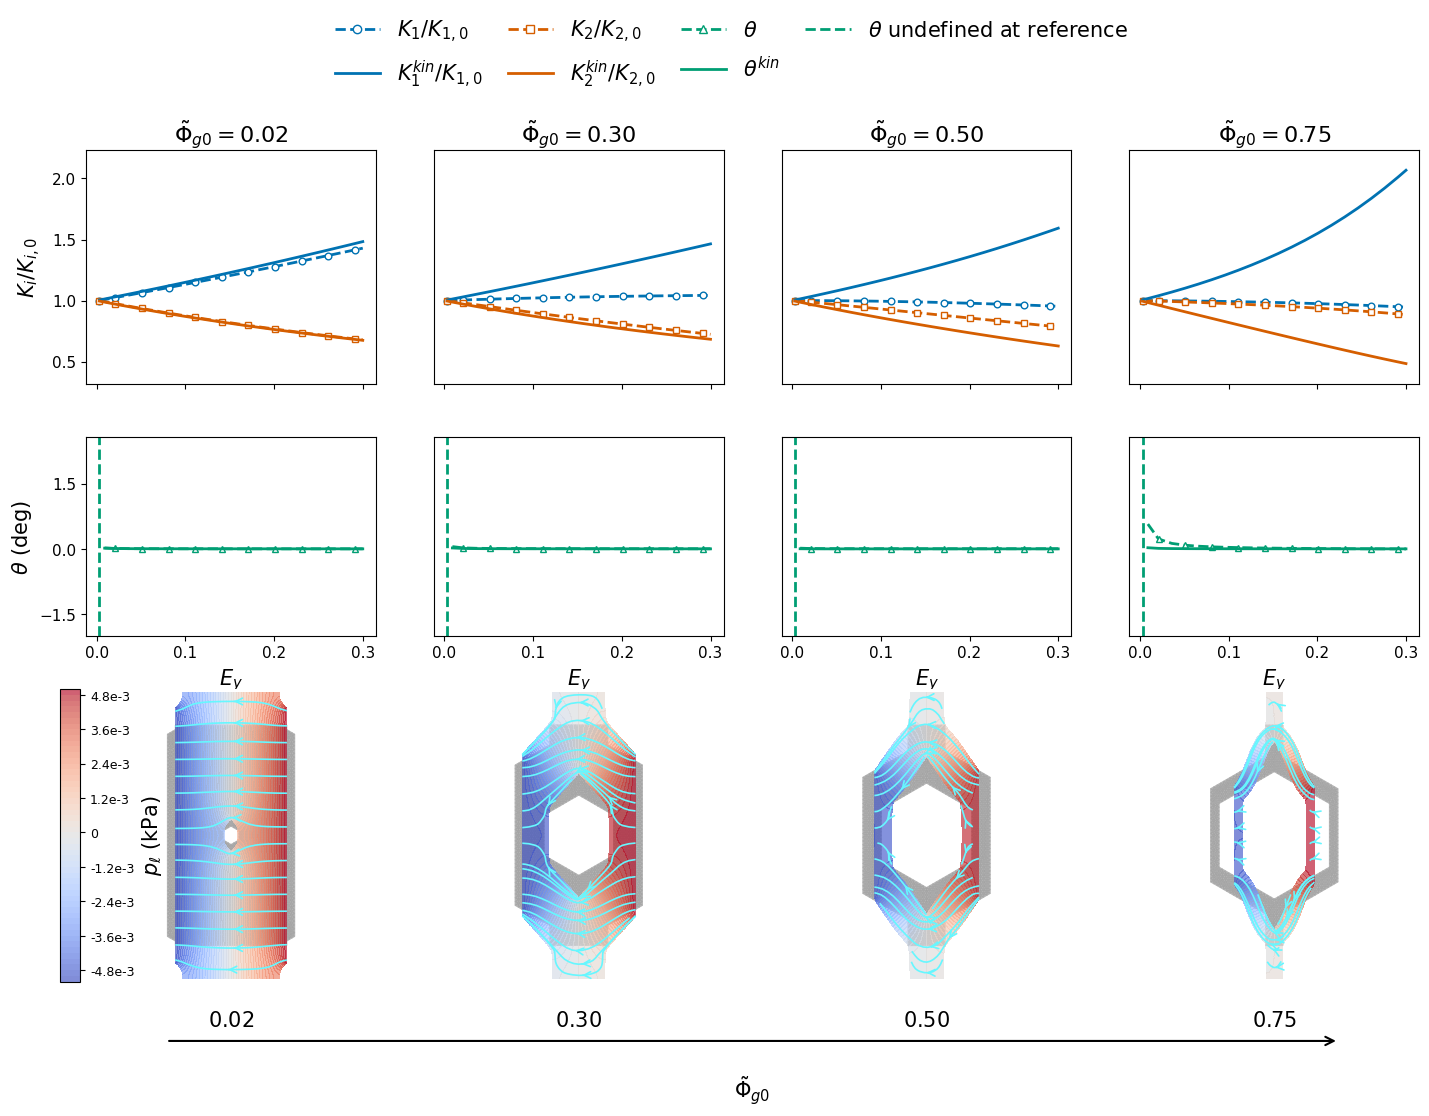

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure6_stretch_y.pdf


In [8]:
figure_path = build_deformation_figure(
    mode="stretch-y",
    res_folder=res_folders["stretch-y"],
    r0_list=r0_list,
)

## Figure 7

r0 = 0.072, pf = 0.0
K1_0 = 9.72371410461091e-07
K2_0 = 9.668203258876297e-07
max asymmetry = 2.6838254918787567e-08


/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:540: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf0 = mesh0.extract_surface().triangulate()
/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:557: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surf = warped.extract_surface().triangulate()


r0 = 0.315, pf = 0.0
K1_0 = 5.357628683373667e-07
K2_0 = 5.342967212359878e-07
max asymmetry = 1.1445269704098866e-07
r0 = 0.41, pf = 0.0
K1_0 = 3.24294361746528e-07
K2_0 = 3.2385452103089883e-07
max asymmetry = 1.499987778066141e-07
r0 = 0.5, pf = 0.0
K1_0 = 1.4139347422845384e-07
K2_0 = 1.4135369054121466e-07
max asymmetry = 3.2667312330614606e-08


/Users/xiao/PhD/Project_MicroPoroFlow/src/Plot_Microporoflow.py:1244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


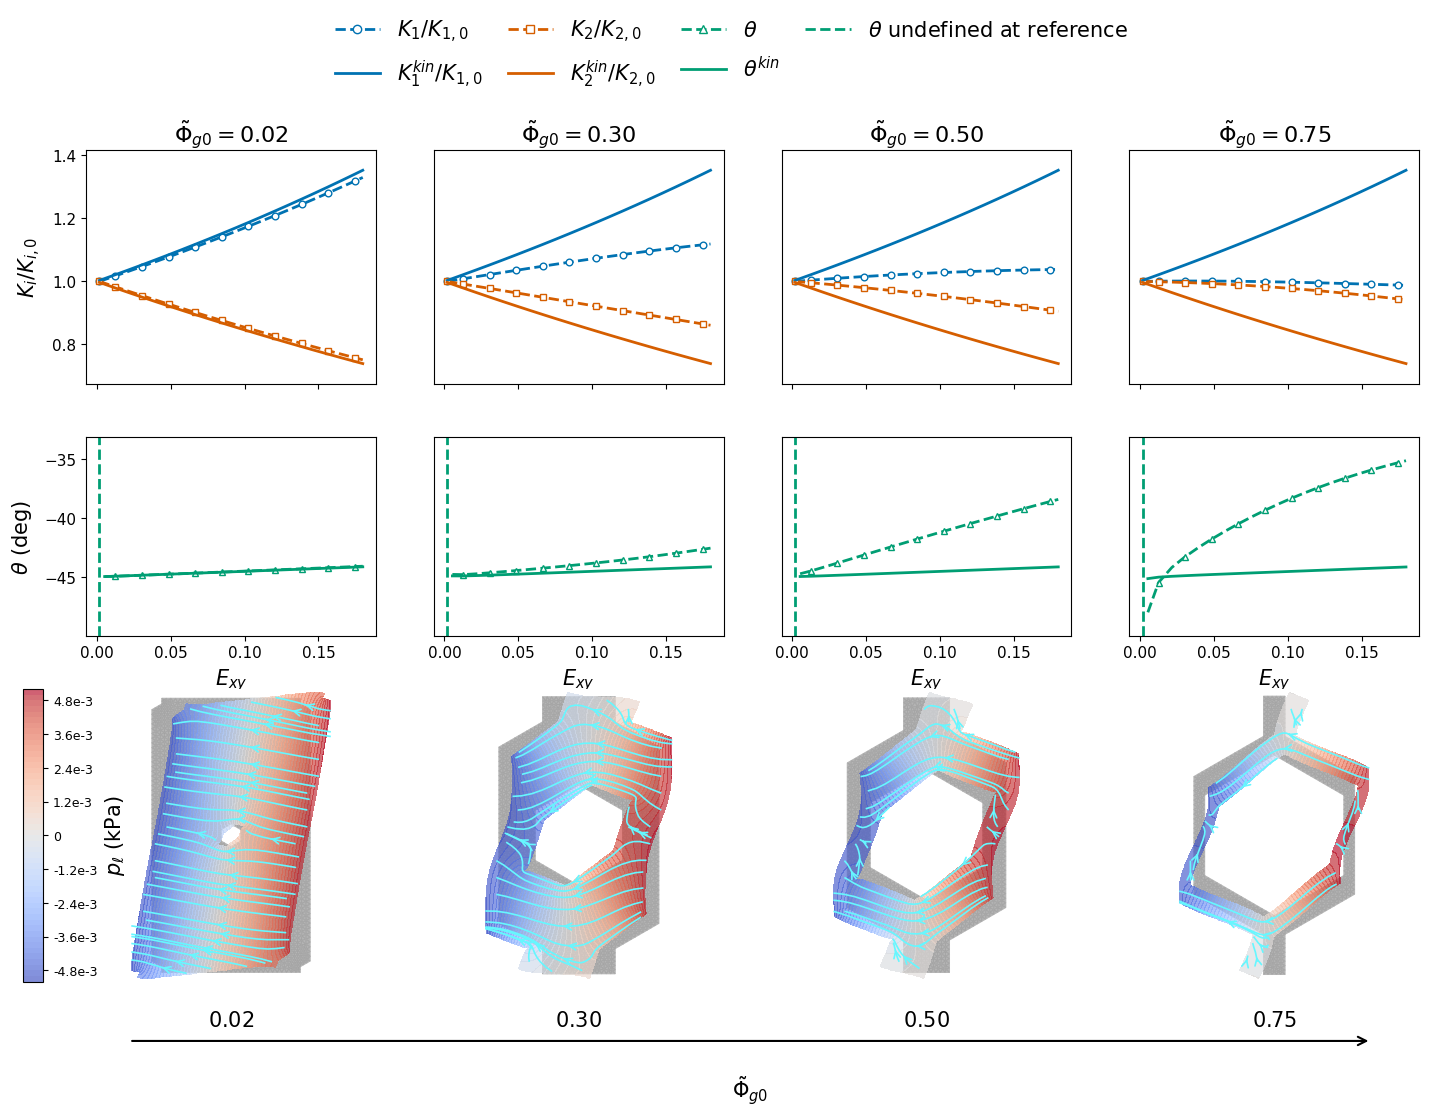

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure7_shear.pdf


In [9]:
figure_path = build_deformation_figure(
    mode="shear",
    res_folder=res_folders["shear"],
    r0_list=r0_list,
)